# Working with WSI and MSI files

This notebook introduces the `WSI` and `MSI` classes independently, then applies common transforms to each modality. It uses the sample bundled in `examples/data`.

Install the notebook dependencies with `pip install "imzdesk[examples]"`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import imzdesk.transforms as T
from imzdesk.io import MSI, WSI
from imzdesk.visualization import DImageDisplay

## Select the files

The path setup below works when Jupyter starts in either the repository root or the `examples` directory. Replace `SAMPLE_DIR` to use another paired sample. An imzML file requires its matching `.ibd` file beside it.

In [2]:
working_dir = Path.cwd()
if (working_dir / 'examples' / 'data').is_dir():
    examples_dir = working_dir / 'examples'
elif (working_dir / 'data').is_dir():
    examples_dir = working_dir
else:
    raise FileNotFoundError('Start Jupyter in the repository root or examples directory.')

SAMPLE_DIR = examples_dir / 'data' / 'MTBLS289' / 'A52 5cm S4'
WSI_PATH = SAMPLE_DIR / 'NICOLE A52 5CM 20.06.13 (4) - 2014-05-27 16.33.21.ndpi'
MSI_PATH = SAMPLE_DIR / 'A52 5cm S4-profile.imzML'

assert WSI_PATH.is_file(), WSI_PATH
assert MSI_PATH.is_file(), MSI_PATH
assert MSI_PATH.with_suffix('.ibd').is_file(), MSI_PATH.with_suffix('.ibd')

## Whole-slide images

`WSI` wraps an OpenSlide image. It exposes slide metadata and pyramid access without loading the full-resolution image into memory. Spatial resolution is stored axis-wise as microns per pixel (MPP).

In [3]:
wsi = WSI(WSI_PATH)

print('file:', wsi.filepath.name)
print('level-0 dimensions:', wsi.slide.dimensions)
print('pyramid levels:', wsi.slide.level_dimensions)
print('MPP:', (wsi.metadata.mpp.x, wsi.metadata.mpp.y))
print('vendor:', wsi.metadata.vendor)
print('objective power:', wsi.metadata.objective_power)

file: NICOLE A52 5CM 20.06.13 (4) - 2014-05-27 16.33.21.ndpi
level-0 dimensions: (135168, 37120)
pyramid levels: ((135168, 37120), (67584, 18560), (33792, 9280), (16896, 4640), (8448, 2320), (4224, 1160), (2112, 580), (1056, 290), (528, 145))
MPP: (0.22710240047237298, 0.2270972430394695)
vendor: hamamatsu
objective power: 40.0


### Rasterization and tissue masking

`ToImage` selects an appropriate pyramid level and returns an RGB NumPy array at the requested physical resolution. `OpticalDensity` converts RGB brightness into a scalar stain-density image, and `Threshold` produces a boolean tissue mask. `Compose` runs these callable transforms in order.

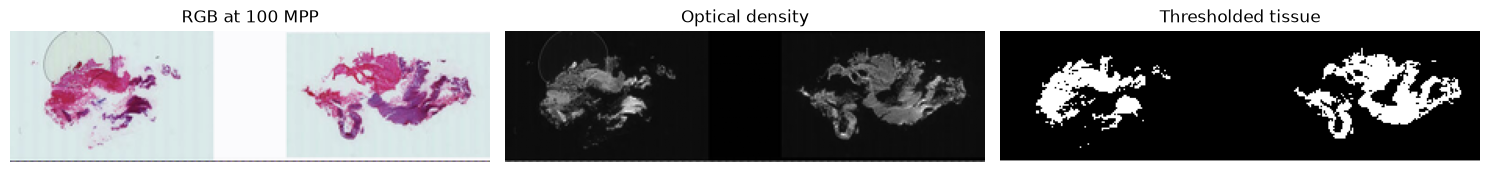

In [4]:
WSI_OVERVIEW_MPP = 100.0

wsi_rgb = T.ToImage(target_mpp=WSI_OVERVIEW_MPP, crop=False)(wsi)
wsi_density = T.Compose([
    T.ToImage(target_mpp=WSI_OVERVIEW_MPP, crop=False),
    T.OpticalDensity(),
])(wsi)
wsi_mask = T.Threshold()(wsi_density)

figure, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(wsi_rgb)
axes[0].set_title(f'RGB at {WSI_OVERVIEW_MPP:g} MPP')
axes[1].imshow(wsi_density, cmap='gray')
axes[1].set_title('Optical density')
axes[2].imshow(wsi_mask, cmap='gray')
axes[2].set_title('Thresholded tissue')
for axis in axes:
    axis.axis('off')
plt.tight_layout()

### Reading a region

`read_region` accepts a level-zero `(x, y)` location, an exact output `(height, width)`, and an optional target MPP. This is the efficient path for patch-based analysis because OpenSlide reads only the required pyramid region. Here the coarser optical-density overview selects a tissue location before a higher-resolution patch is read.

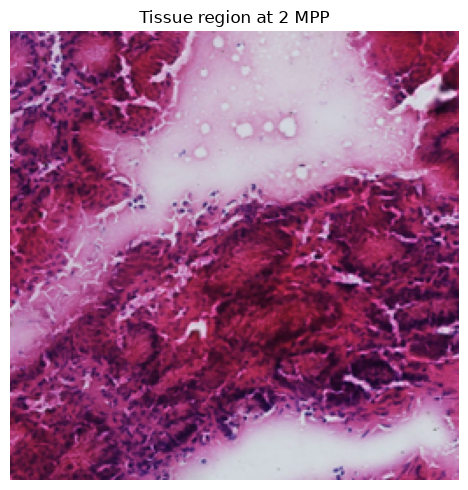

In [5]:
PATCH_SHAPE = (256, 256)
PATCH_MPP = 2.0
native_dimensions = np.array(wsi.slide.dimensions)
native_mpp = np.array([wsi.metadata.mpp.x, wsi.metadata.mpp.y])
tissue_y, tissue_x = np.unravel_index(np.argmax(wsi_density), wsi_density.shape)
tissue_center = np.array([tissue_x, tissue_y]) * WSI_OVERVIEW_MPP / native_mpp
patch_extent_level0 = np.array([PATCH_SHAPE[1], PATCH_SHAPE[0]]) * PATCH_MPP / native_mpp
location = np.clip(tissue_center - patch_extent_level0 / 2, 0, native_dimensions - patch_extent_level0)
wsi_patch = wsi.read_region(location, PATCH_SHAPE, target_mpp=PATCH_MPP)

plt.figure(figsize=(5, 5))
plt.imshow(wsi_patch)
plt.title(f'Tissue region at {PATCH_MPP:g} MPP')
plt.axis('off')
plt.tight_layout()

## Mass spectrometry images

`MSI` wraps an imzML acquisition and reads spectra lazily from its `.ibd` file. `cache_portable=False` keeps this example from writing the optional portable `.h5` parser cache. On first metadata access, imzDesk still creates its normal `.imzDesk/*.meta.yaml` sidecar if one does not exist. Coordinates come from the acquisition and may be one-based.

In [6]:
msi = MSI(MSI_PATH, cache_portable=False)

print('file:', msi.filepath.name)
print('pixels:', len(msi))
print('coordinate array:', msi.coordinates.shape)
print('declared dimensions:', (msi.metadata.width, msi.metadata.height))
print('MPP:', (msi.metadata.mpp.x, msi.metadata.mpp.y))

file: A52 5cm S4-profile.imzML
pixels: 4182
coordinate array: (4182, 3)
declared dimensions: (51, 82)
MPP: (135.0, 135.0)


### Reading one spectrum

Open the MSI as a context manager before using index access or `at(x, y)`. Both return aligned one-dimensional arrays containing m/z positions and intensities.

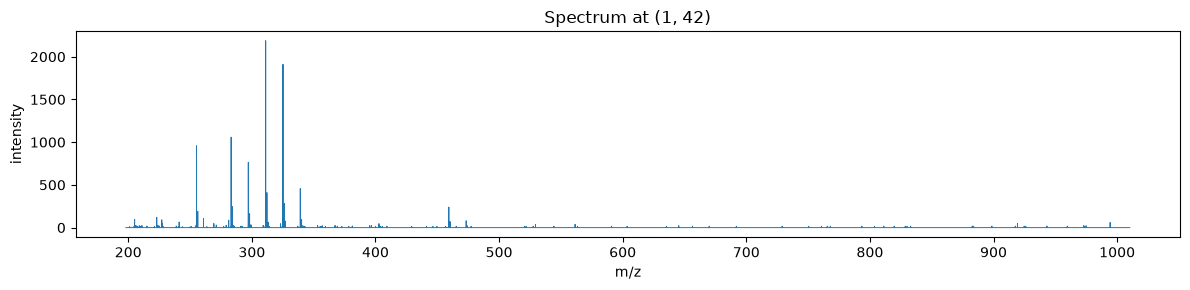

In [7]:
coordinate = msi.coordinates[len(msi) // 2]
x, y = map(int, coordinate[:2])
with msi:
    mz, intensity = msi.at(x, y)

plt.figure(figsize=(12, 3))
plt.plot(mz, intensity, linewidth=0.7)
plt.xlabel('m/z')
plt.ylabel('intensity')
plt.title(f'Spectrum at ({x}, {y})')
plt.tight_layout()

### From ragged spectra to shared features

Raw spectra become an `RImage`, which stores variable-length m/z and intensity arrays. `Normalize('tic')` normalizes each pixel independently. `Bin` places all spectra on a common m/z basis and returns an `SImage` backed by a SciPy sparse matrix.

In [8]:
ragged = T.ToRImage()(msi)
normalized = T.Normalize('tic')(ragged)
bin_spectra = T.Bin(
    minimum_channel=50.0,
    maximum_channel=1000.0,
    bin_width=2.0,
)
raw_binned = bin_spectra(ragged)
binned = bin_spectra(normalized)

print('ragged:', type(ragged).__name__, ragged.values.shape)
print('binned:', type(binned).__name__, binned.values.shape)
print('nonzero binned values:', binned.values.nnz)

ragged: RImage (17860105,)
binned: SImage (4182, 475)
nonzero binned values: 674861


### Scalar and multichannel images

`TIC` sums each raw binned feature vector into a scalar `DImage`. PCA uses the TIC-normalized features and requires dense input, so `ToDense` precedes `PCA`. `DImageDisplay` maps acquisition coordinates back onto an image grid and scales one or three channels for display.

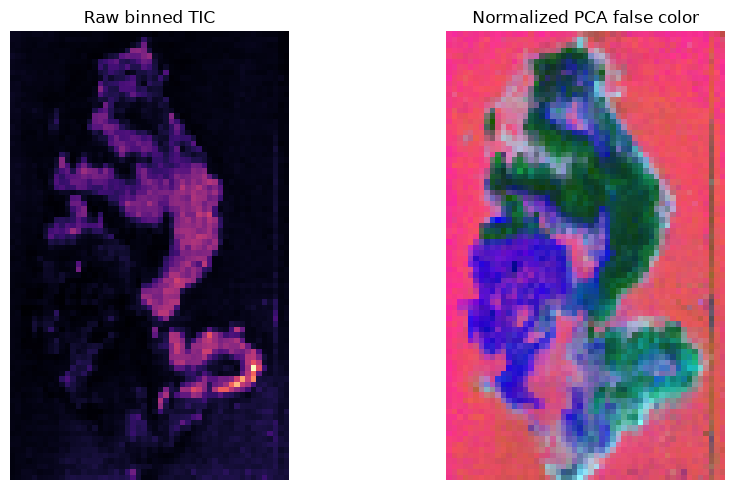

In [9]:
tic_image = T.TIC()(raw_binned)
pca_image = T.Compose([
    T.ToDense(),
    T.PCA(number_of_components=3, random_seed=0),
])(binned)

figure, axes = plt.subplots(1, 2, figsize=(10, 5))
DImageDisplay(tic_image, colormap='magma').plot(axes[0])
axes[0].set_title('Raw binned TIC')
DImageDisplay(pca_image).plot(axes[1])
axes[1].set_title('Normalized PCA false color')
plt.tight_layout()

### Reusable MSI pipeline

The same steps can be assembled into one callable `Compose`. This scalar pipeline uses `log1p` compression without per-pixel TIC normalization, then ends with `ToImage` to return an ordinary NumPy raster suitable for plotting or downstream array code.

raster shape: (83, 52)


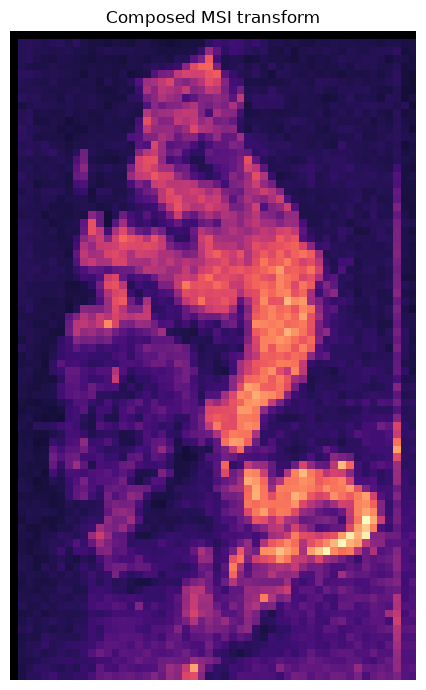

In [10]:
msi_pipeline = T.Compose([
    T.ToRImage(),
    T.Normalize('log1p'),
    T.Bin(minimum_channel=50.0, maximum_channel=1000.0, bin_width=2.0),
    T.TIC(),
    T.ToImage(),
])
msi_raster = msi_pipeline(msi)

print('raster shape:', msi_raster.shape)
plt.figure(figsize=(5, 7))
plt.imshow(msi_raster, cmap='magma')
plt.title('Composed MSI transform')
plt.axis('off')
plt.tight_layout()